In [1]:
MODEL_CLS = "affection"
DATASET = "amusic"
STRATEGY = "pointwise"
PATH_WORK_DIR = "../.."

In [2]:
if DATASET=="abeauty":
    NUM_USERS = 3819
    NUM_ITEMS = 1581
elif DATASET=="amusic":
    NUM_USERS = 5541
    NUM_ITEMS = 3568
elif DATASET=="lastfm":
    NUM_USERS = 1892
    NUM_ITEMS = 17632
elif DATASET=="movielens":
    NUM_USERS = 610
    NUM_ITEMS = 9724
else:
    raise ValueError()

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PAPER REVIEW\RECSYS\02_MLP\10_RS-DRNet


In [5]:
import sys
sys.path.append("src")

# Config

In [6]:
import pandas as pd
from pointwise import config, datamodule, trainer, evaluator, utils
import drnet

In [7]:
PATH = f"./config/{MODEL_CLS}_{STRATEGY}.yaml"
cfg = config.build(PATH)

In [8]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [9]:
PATH = f"./data/{DATASET}.csv"
df = pd.read_csv(PATH)

In [10]:
kwargs = dict(
    df=df,
    percentile=0.9,
)

utils.desc.main(**kwargs)

number of user: 5541
number of item: 3568
total interaction: 64706
interaction density: 0.3273 %
max interaction of user: 578
max interaction of item: 272
top 10.0 % interaction of user: 20.0
top 10.0 % interaction of item: 40.0
mean interaction of user: 11
mean interaction of item: 18


In [11]:
kwargs = dict(
    df=df,
    cfg=cfg.datamodule,
)

dataloaders, _ = datamodule.build(**kwargs)

# Modeling

In [12]:
kwargs = dict(
    num_users=NUM_USERS,
    num_items=NUM_ITEMS,
    **cfg.model.params,
)

model = drnet.affection.AffectionNetworks(**kwargs)

# Train

In [13]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

opt = trainer.build(**kwargs)

In [14]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = opt.fit(**kwargs)

BEST EPOCH: 38
BEST SCORE: 0.4237


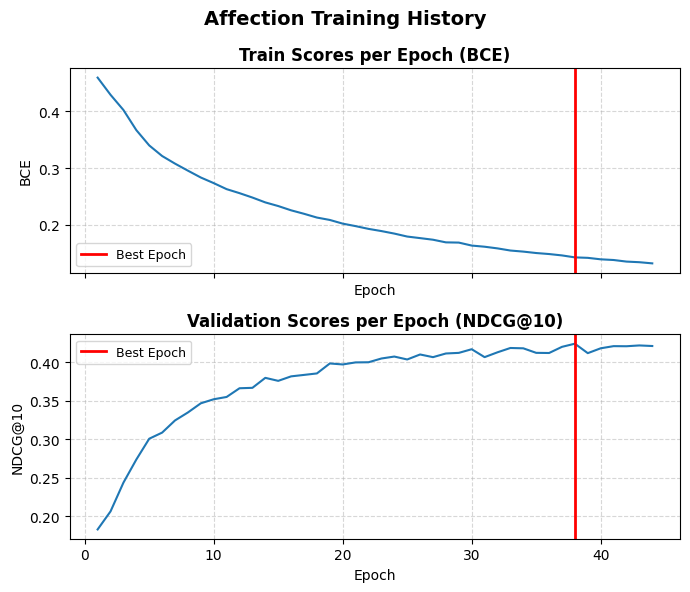

In [15]:
kwargs = dict(
    records=records,
    suptitle="Affection Training History",
    trn="BCE",
    val="NDCG@10",
    figsize=(7,3),
)

utils.visualizer.main(**kwargs)

# Test

In [16]:
kwargs = dict(
    model=model,
    cutoff=[5,10,15,20,25,50],
)

msr = evaluator.build(**kwargs)

In [17]:
result, metrics_sheet = msr(dataloaders["tst"])

TST:   0%|          | 0/760 [00:00<?, ?it/s]

TST: 100%|██████████| 760/760 [00:03<00:00, 229.80it/s]


In [18]:
metrics_sheet

,k,hit_ratio,precision,recall,map,ndcg
0,5,0.545930,0.116946,0.497587,0.317968,0.371787
1,10,0.682729,0.076033,0.631126,0.337974,0.416720
2,15,0.752391,0.057451,0.704034,0.344776,0.437244
3,20,0.800758,0.046670,0.754956,0.348195,0.450082
4,25,0.833965,0.039531,0.791127,0.350144,0.458669
5,50,0.933225,0.023054,0.902388,0.354128,0.481749


# Save

In [19]:
PATH = f'./checkpoints/{DATASET}/{MODEL_CLS}_{STRATEGY}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)